                                                XGBClassifier

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")

df.drop('objid', axis=1, inplace=True)

#  Feature Engineering 

df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

# Data Cleaning
df = df[(df['u-g'] > -5) & (df['u-g'] < 5) &
        (df['g-r'] > -5) & (df['g-r'] < 5)]

# Encode Labels 

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

print(le.classes_)

['GALAXY' 'QSO' 'STAR']


In [3]:
# Features & Target 

X = df.drop('class', axis=1)
y = df['class']


feature_names = X.columns

#  Train-Test Split 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [4]:
#  Scaling 

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:


xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,            
    colsample_bytree=0.8,     
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [6]:
# Predictions 

y_pred = xgb.predict(X_test)

In [7]:
#  Evaluation

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.993866477942911

Confusion Matrix:
[[17521    34    23]
 [  124  2642     0]
 [    1     0  9328]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.99      0.96      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.98      0.99     29673
weighted avg       0.99      0.99      0.99     29673



In [8]:
# Hyperparameter Tuning
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

best_score = 0
best_params = None

for depth in param_grid["max_depth"]:
    for lr in param_grid["learning_rate"]:
        for n in param_grid["n_estimators"]:
            
            model = XGBClassifier(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='multi:softprob',
                num_class=3,
                eval_metric='mlogloss',
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)

            print(f"depth={depth}, lr={lr}, n={n} → acc={acc:.4f}")

            if acc > best_score:
                best_score = acc
                best_params = (depth, lr, n)

print("\nBest Params:", best_params)
print("Best Accuracy:", best_score)

depth=4, lr=0.05, n=100 → acc=0.9924
depth=4, lr=0.05, n=200 → acc=0.9931
depth=4, lr=0.1, n=100 → acc=0.9933
depth=4, lr=0.1, n=200 → acc=0.9936
depth=6, lr=0.05, n=100 → acc=0.9934
depth=6, lr=0.05, n=200 → acc=0.9936
depth=6, lr=0.1, n=100 → acc=0.9937
depth=6, lr=0.1, n=200 → acc=0.9939
depth=8, lr=0.05, n=100 → acc=0.9934
depth=8, lr=0.05, n=200 → acc=0.9938
depth=8, lr=0.1, n=100 → acc=0.9936
depth=8, lr=0.1, n=200 → acc=0.9936

Best Params: (6, 0.1, 200)
Best Accuracy: 0.993866477942911


In [9]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

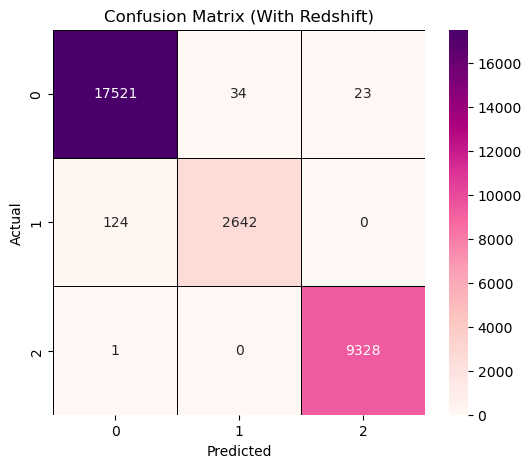

In [10]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (With Redshift)")

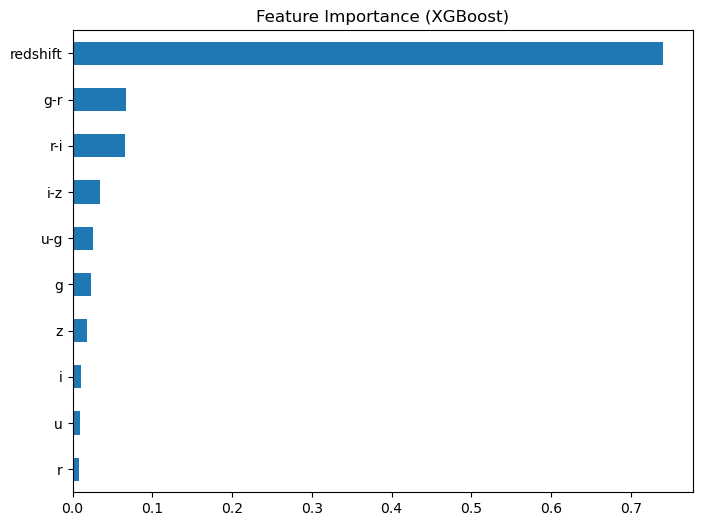

In [11]:
import seaborn as sns

feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

                                                            Without Redshift

In [12]:
#  REMOVE REDSHIFT 


X_train = np.delete(X_train, 5, axis=1)
X_test = np.delete(X_test, 5, axis=1)

feature_names = list(feature_names)
feature_names.remove('redshift')

In [13]:


xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,           
    colsample_bytree=0.8,    
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [14]:
#  Predictions 

y_pred = xgb.predict(X_test)


In [15]:
#  Evaluation 

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9326997607252384

Confusion Matrix:
[[17134    91   353]
 [  151  2278   337]
 [  776   289  8264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17578
           1       0.86      0.82      0.84      2766
           2       0.92      0.89      0.90      9329

    accuracy                           0.93     29673
   macro avg       0.91      0.89      0.90     29673
weighted avg       0.93      0.93      0.93     29673



In [16]:
# Hyperparameter Tuning
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

param_grid = {
    "max_depth": [4, 6, 8],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [100, 200]
}

best_score = 0
best_params = None

for depth in param_grid["max_depth"]:
    for lr in param_grid["learning_rate"]:
        for n in param_grid["n_estimators"]:
            
            model = XGBClassifier(
                max_depth=depth,
                learning_rate=lr,
                n_estimators=n,
                subsample=0.8,
                colsample_bytree=0.8,
                objective='multi:softprob',
                num_class=3,
                eval_metric='mlogloss',
                random_state=42,
                n_jobs=-1
            )

            model.fit(X_train, y_train)
            preds = model.predict(X_test)
            acc = accuracy_score(y_test, preds)

            print(f"depth={depth}, lr={lr}, n={n} → acc={acc:.4f}")

            if acc > best_score:
                best_score = acc
                best_params = (depth, lr, n)

print("\nBest Params:", best_params)
print("Best Accuracy:", best_score)

depth=4, lr=0.05, n=100 → acc=0.9121
depth=4, lr=0.05, n=200 → acc=0.9206
depth=4, lr=0.1, n=100 → acc=0.9210
depth=4, lr=0.1, n=200 → acc=0.9269
depth=6, lr=0.05, n=100 → acc=0.9272
depth=6, lr=0.05, n=200 → acc=0.9306
depth=6, lr=0.1, n=100 → acc=0.9312
depth=6, lr=0.1, n=200 → acc=0.9327
depth=8, lr=0.05, n=100 → acc=0.9320
depth=8, lr=0.05, n=200 → acc=0.9326
depth=8, lr=0.1, n=100 → acc=0.9326
depth=8, lr=0.1, n=200 → acc=0.9329

Best Params: (8, 0.1, 200)
Best Accuracy: 0.9328682640784551


In [17]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

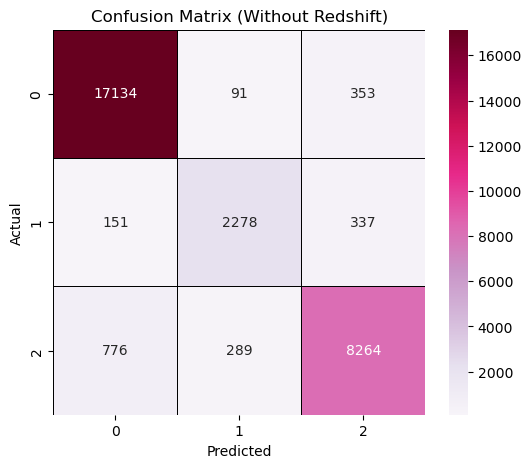

In [18]:
plot_conf_matrix(y_test, y_pred, "Confusion Matrix (Without Redshift)")

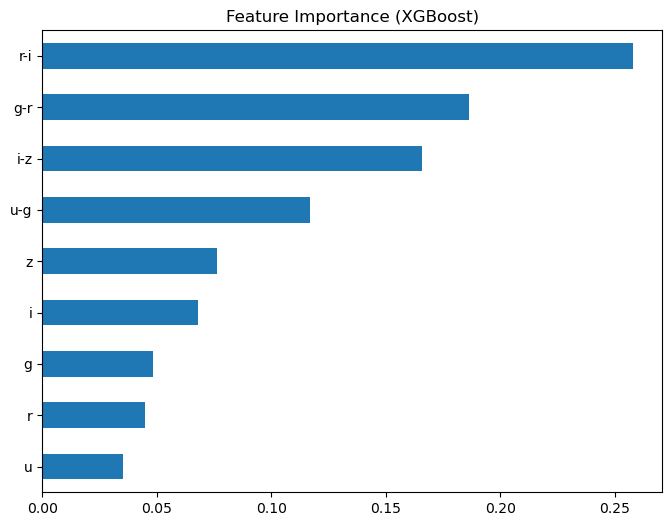

In [19]:
feat_imp = pd.Series(xgb.feature_importances_, index=feature_names)
feat_imp = feat_imp.sort_values()

plt.figure(figsize=(8,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (XGBoost)")
plt.show()

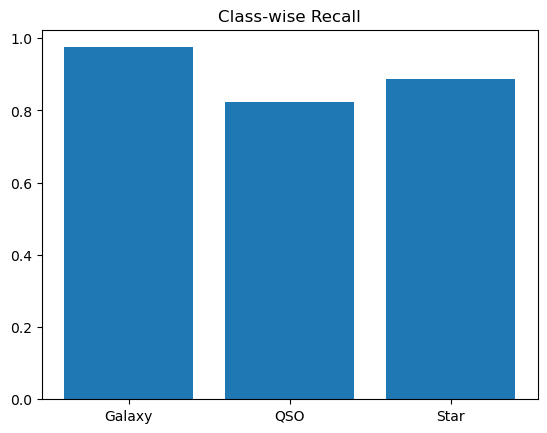

In [20]:
from sklearn.metrics import classification_report

report = classification_report(y_test, y_pred, output_dict=True)

recalls = [report[str(i)]['recall'] for i in range(3)]

plt.bar(['Galaxy','QSO','Star'], recalls)
plt.title("Class-wise Recall")
plt.show()